In [1]:
#Libraries we need

import warnings
warnings.filterwarnings("ignore")

import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.colors

import os

from rasterio.plot import show
from rasterio.plot import plotting_extent
from rasterio.mask import mask

from funciones import nequalize, plot_rgb, delNone

from sklearn import tree

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score as kappa
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split

from shapely.geometry import mapping

# os.chdir("C:\\Users\\arell\\Documents\\Sentinel") #Change to the directory where you are working

-------------
# ROIS
----------
## North


In [2]:
#directory where the image is located
zona = 'norte'
path = 'ImagenesSentinel/stack2022'+zona+'.tif'


# NOTE, this is set up for this specific set of bands and in this order:
# Bands 1,2,3,4,5,6,7,8,11 and 12 

s2 = rasterio.open(path) 
s2_bandas = s2.read()
s2_bandas.shape #(number of bands, image height, image width)

(10, 3812, 1750)

In [3]:
# It's messy, but I didn't feel like fixing it.
# The idea is that it takes the shp file we used initially and edits it with the one we made with the ndwi
# If it needs to be re-edited, in the end it must return a dataframe with 2 columns,
# the first the names of the reservoirs (split by Norte and Sur)
# and a second column with the geometry of each one

radios = gpd.read_file('Poligonos/Embalses_unificado.shp')#.set_index('id') #Loads the shp file
radios.drop(columns=['path', 'objeto','entidad','layer'], inplace = True)
radios['id'] = np.linspace(0,10,11).astype(int)
radios.set_index('id')

Norte = ['Cruz del Eje','San Roque','El Cajon']
Sur = ['Cerro Pelado','Los Molinos','Rio Tercero','La ViÃ±a','Usina 3','Piedra Mora','Arroyo Corto']

radiosN = radios.query('fna in @Norte')
radiosS = radios.query('fna in @Sur')
radiosS

Norte_corregidos = ['Cruz del eje', 'El Cajon', 'San Roque']
radiosNorte_in = gpd.read_file('Poligonos/Norte/PoligonosEmbalses18-10.shp')
radiosNorte_in.loc[0].geometry

Sur_corregidos = ['Allende','Cerro Pelado','Rio Tercero','Los Molinos','Arroyo Corto','Usina 3','Sin Nombre2','Piedra Mora']
radiosSur_in = gpd.read_file('Poligonos/Sur/PoligonosEmbalsesSur18-10.shp')
radiosSur_in.loc[2].geometry

radiosSur = radiosSur_in.assign(fna=Sur_corregidos)
radiosNorte = radiosNorte_in.assign(fna=Norte_corregidos)

radiosSur.set_index('fna')
radiosSur.drop(columns=['id'], inplace = True)
radiosSur = radiosSur[['fna','geometry']]

radiosNorte.set_index('fna')
radiosNorte.drop(columns=['id'], inplace = True)
radiosNorte = radiosNorte[['fna','geometry']]
radiosSur

,fna,geometry
0,Allende,"POLYGON ((309760 6477420, 309780 6477420, 3097..."
1,Cerro Pelado,"POLYGON ((344100 6437120, 344120 6437120, 3441..."
2,Rio Tercero,"POLYGON ((365320 6440880, 365380 6440880, 3653..."
3,Los Molinos,"POLYGON ((354400 6483300, 354420 6483300, 3544..."
4,Arroyo Corto,"POLYGON ((351300 6434980, 351320 6434980, 3513..."
5,Usina 3,"POLYGON ((371960 6438900, 371980 6438900, 3719..."
6,Sin Nombre2,"POLYGON ((367740 6441120, 367760 6441120, 3677..."
7,Piedra Mora,"POLYGON ((380320 6441800, 380360 6441800, 3803..."


In [4]:
radiosNorte

,fna,geometry
0,Cruz del eje,"POLYGON ((332180.77 6595124.339, 332215.686 65..."
1,El Cajon,"POLYGON ((351041.243 6585831.893, 351043.737 6..."
2,San Roque,"POLYGON ((361134.245 6532611.069, 361106.812 6..."


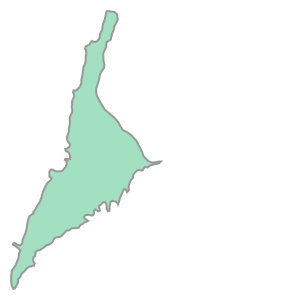

In [5]:
IDEmbalse = 2
nombre = radiosNorte.loc[IDEmbalse].fna
poligono = radiosNorte.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
poligono

In [6]:
s2_plot_extent = plotting_extent(s2) #Bounds of the region to plot
s2_plot_extent

# Plot of the image with the polygons overlaid
bandasPosicion = [3,2,1] # RGB in this set of bands

# img = nequalize(s2_bandas[bandasPosicion], p=5, nodata = None)
# fig, ax = plt.subplots(figsize = (15,8))
# show(img, ax=ax, extent = s2_plot_extent, cmap = 'gray')
# if zona == 'norte':
#     radiosN.boundary.plot(ax=ax, edgecolor = 'red')
# elif zona == 'sur':
#     radiosS.boundary.plot(ax=ax, edgecolor = 'red')
# else:
#     print('Zona must be norte or sur')


<Axes: >

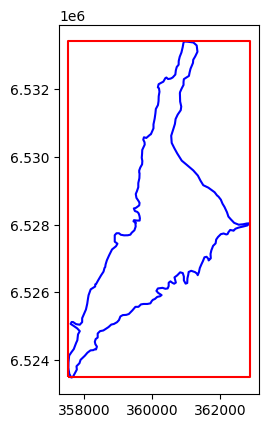

In [7]:
# CROP THE AREA OF INTEREST
extent = poligono.envelope

data = [poligono, extent]
gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

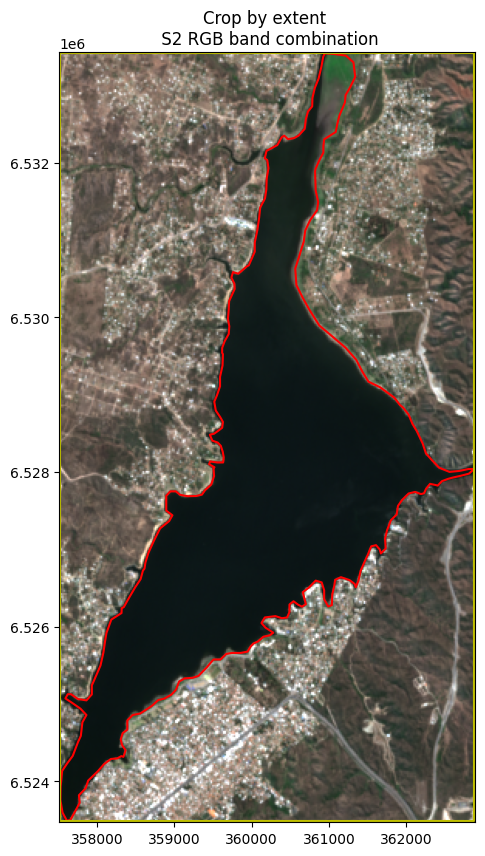

In [8]:
bandasPosicion = [3,2,1] # RGB
# bandasPosicion = [0,1,2] # RGB

s2_clip, clip_transform = mask(dataset = s2, shapes = [extent], crop = True)
fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_clip[bandasPosicion],p=0.5,nodata = None), ax=ax, transform=clip_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by extent \n S2 RGB band combination")
plt.show()

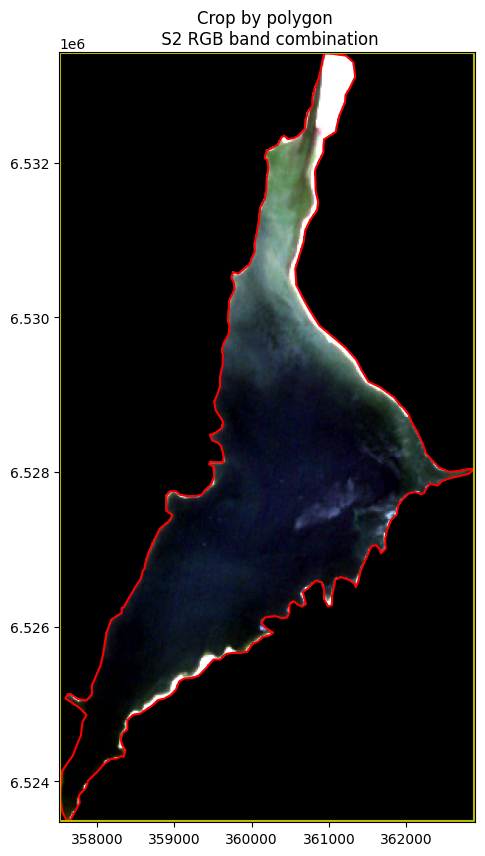

In [9]:
# Keep only what is inside the vector mask
s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_mask[bandasPosicion], p=5), ax=ax, transform=mask_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

-------------
# Molinos
-------------

In [10]:
path = 'ImagenesSentinel/StackRecortado_Molinos_B1a8_11_12.tif'
s2 = rasterio.open(path) 
s2_bandas = s2.read()
s2_bandas.shape #(number of bands, image height, image width)

(10, 652, 408)

In [11]:
radiosM = gpd.read_file('Poligonos/Entrenamiento_2022/TrainingMolinosPoligonos.shp')
names = list(set(radiosM['MC_name']))  # keep all classes present (dropping [1:] here used to silently discard one class)

In [12]:
radiosMol = radiosM.query('MC_name in @names')
radiosMol

,fid,MC_ID,MC_name,C_ID,C_name,SCP_UID,geometry
0,1,1,Agua Clara,1,Agua Clara,AguaClara_1,"POLYGON ((354841.63 6480560.34, 354701.63 6480..."
1,2,1,Agua Clara,1,Agua Clara,AguaClara_2,"POLYGON ((354781.63 6478300.34, 354641.63 6478..."
2,3,1,Agua Clara,1,Agua Clara,AguaClara_3,"POLYGON ((353621.63 6472300.34, 353481.63 6472..."
3,4,1,Agua Clara,1,Agua Clara,AguaClara_4,"POLYGON ((354461.63 6474600.34, 354321.63 6474..."
4,5,1,Agua Clara,1,Agua Clara,AguaClara_5,"POLYGON ((354641.63 6481440.34, 354501.63 6481..."
5,6,1,Agua Clara,1,Agua Clara,AguaClara_6,"POLYGON ((354461.63 6479120.34, 354321.63 6479..."
6,7,1,Agua Clara,1,Agua Clara,AguaClara_7,"POLYGON ((355321.63 6478920.34, 355181.63 6478..."
7,8,1,Agua Clara,1,Agua Clara,AguaClara_8,"POLYGON ((354081.63 6477240.34, 353941.63 6477..."
8,9,2,Alga Difusa,2,Alga Difusa,AlgaDifusa_9,"MULTIPOLYGON (((353061.63 6479340.34, 353061.6..."
9,10,2,Alga Difusa,2,Alga Difusa,AlgaDifusa_10,"MULTIPOLYGON (((353821.63 6479100.34, 353821.6..."


In [13]:
radiosMol['CLASE'] = radiosMol['MC_name']
radiosMol.drop(columns=['fid', 'MC_ID','MC_name','C_ID', 'C_name', 'SCP_UID'], inplace = True)
radiosMol

,geometry,CLASE
0,"POLYGON ((354841.63 6480560.34, 354701.63 6480...",Agua Clara
1,"POLYGON ((354781.63 6478300.34, 354641.63 6478...",Agua Clara
2,"POLYGON ((353621.63 6472300.34, 353481.63 6472...",Agua Clara
3,"POLYGON ((354461.63 6474600.34, 354321.63 6474...",Agua Clara
4,"POLYGON ((354641.63 6481440.34, 354501.63 6481...",Agua Clara
5,"POLYGON ((354461.63 6479120.34, 354321.63 6479...",Agua Clara
6,"POLYGON ((355321.63 6478920.34, 355181.63 6478...",Agua Clara
7,"POLYGON ((354081.63 6477240.34, 353941.63 6477...",Agua Clara
8,"MULTIPOLYGON (((353061.63 6479340.34, 353061.6...",Alga Difusa
9,"MULTIPOLYGON (((353821.63 6479100.34, 353821.6...",Alga Difusa


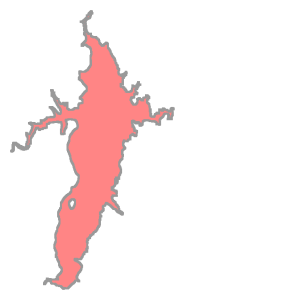

In [14]:
IDEmbalse = 3
nombre = radiosSur.loc[IDEmbalse].fna
poligono = radiosSur.loc[IDEmbalse].geometry #geometry of the eighth element of the shp
poligono

In [15]:
s2_plot_extent = plotting_extent(s2) #Bounds of the region to plot
s2_plot_extent

# Plot of the image with the polygons overlaid
bandasPosicion = [3,2,1] # RGB in this set of bands

# img = nequalize(s2_bandas[bandasPosicion], p=5, nodata = None)
# fig, ax = plt.subplots(figsize = (15,8))
# show(img, ax=ax, extent = s2_plot_extent, cmap = 'gray')
# if zona == 'norte':
#     radiosN.boundary.plot(ax=ax, edgecolor = 'red')
# elif zona == 'sur':
#     radiosS.boundary.plot(ax=ax, edgecolor = 'red')
# else:
#     print('Zona must be norte or sur')


<Axes: >

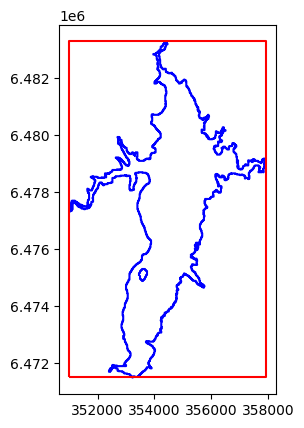

In [16]:
# CROP THE AREA OF INTEREST
extent = poligono.envelope

data = [poligono, extent]
gpd.GeoSeries(data).boundary.plot(color=['b', 'r'])

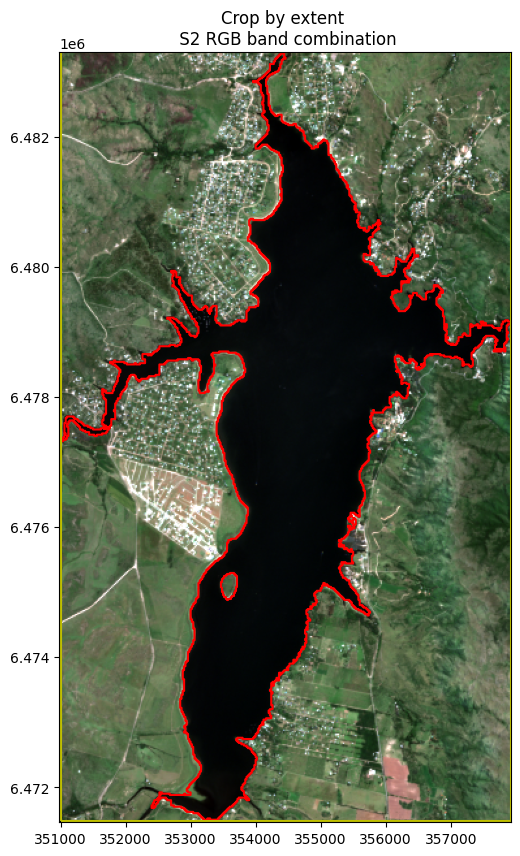

In [17]:
bandasPosicion = [3,2,1] # RGB

s2_clip, clip_transform = mask(dataset = s2, shapes = [extent], crop = True)
fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_clip[bandasPosicion],p=0.5,nodata = None), ax=ax, transform=clip_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by extent \n S2 RGB band combination")
plt.show()

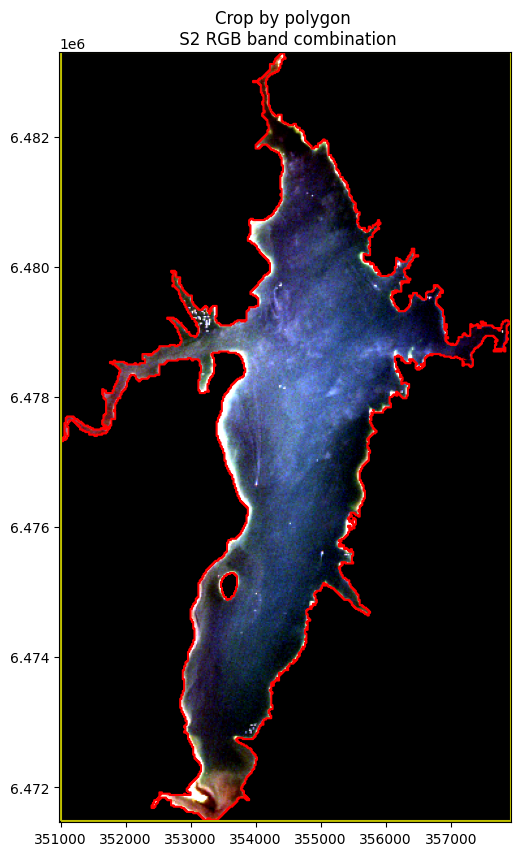

In [18]:
# Keep only what is inside the vector mask
s2_mask, mask_transform  = mask(dataset = s2, shapes = [poligono], crop = True)

fig, ax = plt.subplots(figsize = (10,10))
show(nequalize(s2_mask[bandasPosicion], p=5), ax=ax, transform=mask_transform)
gpd.GeoSeries(data).boundary.plot(ax=ax,color=['r', 'y'])
plt.title("Crop by polygon \n S2 RGB band combination")
plt.show()

------------------
# Supervised Classification

In [19]:
#Load X, Y labeled data, as in the kmeans

#Read the ROIS
with rasterio.open(path) as src:
    d = src.count #number of attributes = number of bands in the raster
    m = src.read()

nodata = -255 #choose an unusual value for nodata, different from None or np.nan (not empty nor infinite)

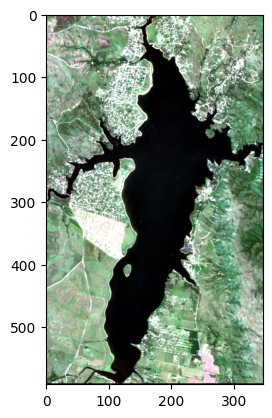

<Axes: >

In [20]:
plt.style.use('default')
show(nequalize(s2_clip[[3,2,1]], nodata = 0))

In [21]:
# The shp file used for training must have at least 2 columns, the first named CLASE with the name of
# each type; I used agua clara, alga densa, and alga difusa. The name chosen doesn't matter.
# The second column is the geometry of each polygon

# pols = gpd.read_file('Poligonos/Entrenamiento_2022/pol180222-2.shp')#.set_index('id') #Loads the shp file with the training polygons for the reservoir
# pols = gpd.read_file('Poligonos/Entrenamiento_2022/polCruz-2.shp')
pols = radiosMol

#In case it doesn't have the same name I used, they can be changed here,
# where in the dictionary for each dataframe value, enter the new name you want,
# for example, from id to id_clase
nombres_col = {'id':'id_clase', 'clase_1':'CLASE'} 
pols.rename(columns = nombres_col, inplace = True)
pols

,geometry,CLASE
0,"POLYGON ((354841.63 6480560.34, 354701.63 6480...",Agua Clara
1,"POLYGON ((354781.63 6478300.34, 354641.63 6478...",Agua Clara
2,"POLYGON ((353621.63 6472300.34, 353481.63 6472...",Agua Clara
3,"POLYGON ((354461.63 6474600.34, 354321.63 6474...",Agua Clara
4,"POLYGON ((354641.63 6481440.34, 354501.63 6481...",Agua Clara
5,"POLYGON ((354461.63 6479120.34, 354321.63 6479...",Agua Clara
6,"POLYGON ((355321.63 6478920.34, 355181.63 6478...",Agua Clara
7,"POLYGON ((354081.63 6477240.34, 353941.63 6477...",Agua Clara
8,"MULTIPOLYGON (((353061.63 6479340.34, 353061.6...",Alga Difusa
9,"MULTIPOLYGON (((353821.63 6479100.34, 353821.6...",Alga Difusa


In [22]:
pols['CLASE'].value_counts() #Number of elements per class

CLASE
Alga Difusa    10
Agua Clara      8
Alga Densa      2
Name: count, dtype: int64

In [23]:
clases=list(set(pols['CLASE']))
clases.sort() #number the ROI classes alphabetically
clase_dict = {clase:i for i, clase in enumerate(clases)}
clase_dict

{'Agua Clara': 0, 'Alga Densa': 1, 'Alga Difusa': 2}

In [24]:
#Prepare collection of labeled attributes. Starts with 0 data points
X = np.zeros([0,d],dtype = np.float32) #array with all the attributes
Y = np.zeros([0],dtype=int)            #array with their labels

with rasterio.open(path) as src:
    for index, row in pols.iterrows():
        poli = row['geometry']
        clase = row['CLASE']
        clip, _transform = mask(src, [poli], crop=True,nodata=None)
        d,x,y = clip.shape
        D = list(clip.reshape([d,x*y]).T)
        D = [p for p in D if (not (p==None).prod())]
        DX = np.array(D)        
        DY = np.repeat(clase_dict[clase],len(D))
        X = np.concatenate((X,DX))
        Y = np.concatenate((Y,DY))

In [25]:
L = list(Y)
E = set(L)

pixels_por_clase = {clases[y]:L.count(y) for y in E}

In [26]:
for clase in clases:
    print(f"{clase:>15s}: {pixels_por_clase[clase]}, 25%: {pixels_por_clase[clase]*0.25}") #Number of pixels per class

     Agua Clara: 392, 25%: 98.0
     Alga Densa: 312, 25%: 78.0
    Alga Difusa: 1651, 25%: 412.75


In [27]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, stratify=Y, test_size = .25)#, random_state=2)  #If I want it to be reproducible, use random_state

In [28]:
#Build and train a *Decision tree*

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
Y_pred = clf.predict(X_test)

In [29]:
# Parameters of interest

M = confusion_matrix(y_test, Y_pred)
print('Confusion matrix:\n',M) #If this gives me a diagonal, be suspicious

acc = accuracy_score(y_test, Y_pred)
print(f'accuracy: {acc:.2f}')

k = kappa(y_test, Y_pred)
print(f'kappa index: {k:.2f}')


Confusion matrix:
 [[ 96   0   2]
 [  0  41  37]
 [  3   4 406]]
accuracy: 0.92
kappa index: 0.82


In [30]:
#Build and train a depth-2 tree

clf4 = DecisionTreeClassifier(max_depth = 15)
clf4 = clf4.fit(X_train, y_train)
Y_pred = clf4.predict(X_test)

acc = accuracy_score(y_test, Y_pred)
print(f'accuracy: {acc:.2f}')

k = kappa(y_test, Y_pred)
print(f'kappa index: {k:.2f}')

accuracy: 0.93
kappa index: 0.83


In [31]:
# bandas = ['Band 1', 'Blue', 'Green', 'Red', 'Band 5', 'Band 6', 'Band 7', 'NIR', 'Band 9', 'SWIR 1', 'SWIR 2']
bandas = ['Band 1', 'Blue', 'Green', 'Red', 'Band 5', 'Band 6', 'Band 7', 'NIR', 'SWIR1', 'SWIR2']

feature_names = bandas

n_nodes = clf4.tree_.node_count
children_left = clf4.tree_.children_left
children_right = clf4.tree_.children_right
feature = clf4.tree_.feature
threshold = clf4.tree_.threshold
hojas = [clases[np.argmax(clf4.tree_.value[i][0])] for i in range(n_nodes)]

n_nodes

37

In [32]:
node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # starts with the root node (0) at depth (0)
while len(stack) > 0:

    node_id, depth = stack.pop() #Make sure each node is visited only once
    node_depth[node_id] = depth

    # If left and right are not the same node, then it's a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]

    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print("The binary tree has a structure with {n} nodes:\n".format(n=n_nodes))
for i in range(n_nodes):
    if is_leaves[i]:
        print("{space}N{node}: LEAF {clase}.".format(
            space=node_depth[i] * "\t", node=i, clase = hojas[i]))
    else:
        print("{space}N{node}: IF ({feature} <= {threshold:.3f}) -> N{left}, ELSE -> N{right}.".format(
                  space=node_depth[i] * "\t",
                  node=i,
                  left=children_left[i],
                  feature=feature_names[feature[i]],
                  threshold=threshold[i],
                  right=children_right[i]))

The binary tree has a structure with 37 nodes:

N0: IF (Green <= 1137.500) -> N1, ELSE -> N6.
	N1: IF (Band 6 <= 1158.500) -> N2, ELSE -> N5.
		N2: IF (Band 7 <= 525.500) -> N3, ELSE -> N4.
			N3: LEAF Alga Difusa.
			N4: LEAF Alga Difusa.
		N5: LEAF Alga Densa.
	N6: IF (Band 5 <= 1119.500) -> N7, ELSE -> N18.
		N7: IF (Band 1 <= 1162.500) -> N8, ELSE -> N15.
			N8: IF (SWIR1 <= 1118.500) -> N9, ELSE -> N14.
				N9: IF (SWIR1 <= 1074.500) -> N10, ELSE -> N11.
					N10: LEAF Agua Clara.
					N11: IF (Red <= 1094.500) -> N12, ELSE -> N13.
						N12: LEAF Alga Difusa.
						N13: LEAF Agua Clara.
				N14: LEAF Alga Difusa.
			N15: IF (Blue <= 1169.000) -> N16, ELSE -> N17.
				N16: LEAF Alga Difusa.
				N17: LEAF Agua Clara.
		N18: IF (Band 7 <= 1255.000) -> N19, ELSE -> N30.
			N19: IF (Band 5 <= 1127.500) -> N20, ELSE -> N23.
				N20: IF (Blue <= 1181.500) -> N21, ELSE -> N22.
					N21: LEAF Alga Difusa.
					N22: LEAF Agua Clara.
				N23: IF (Blue <= 1131.000) -> N24, ELSE -> N29.
					

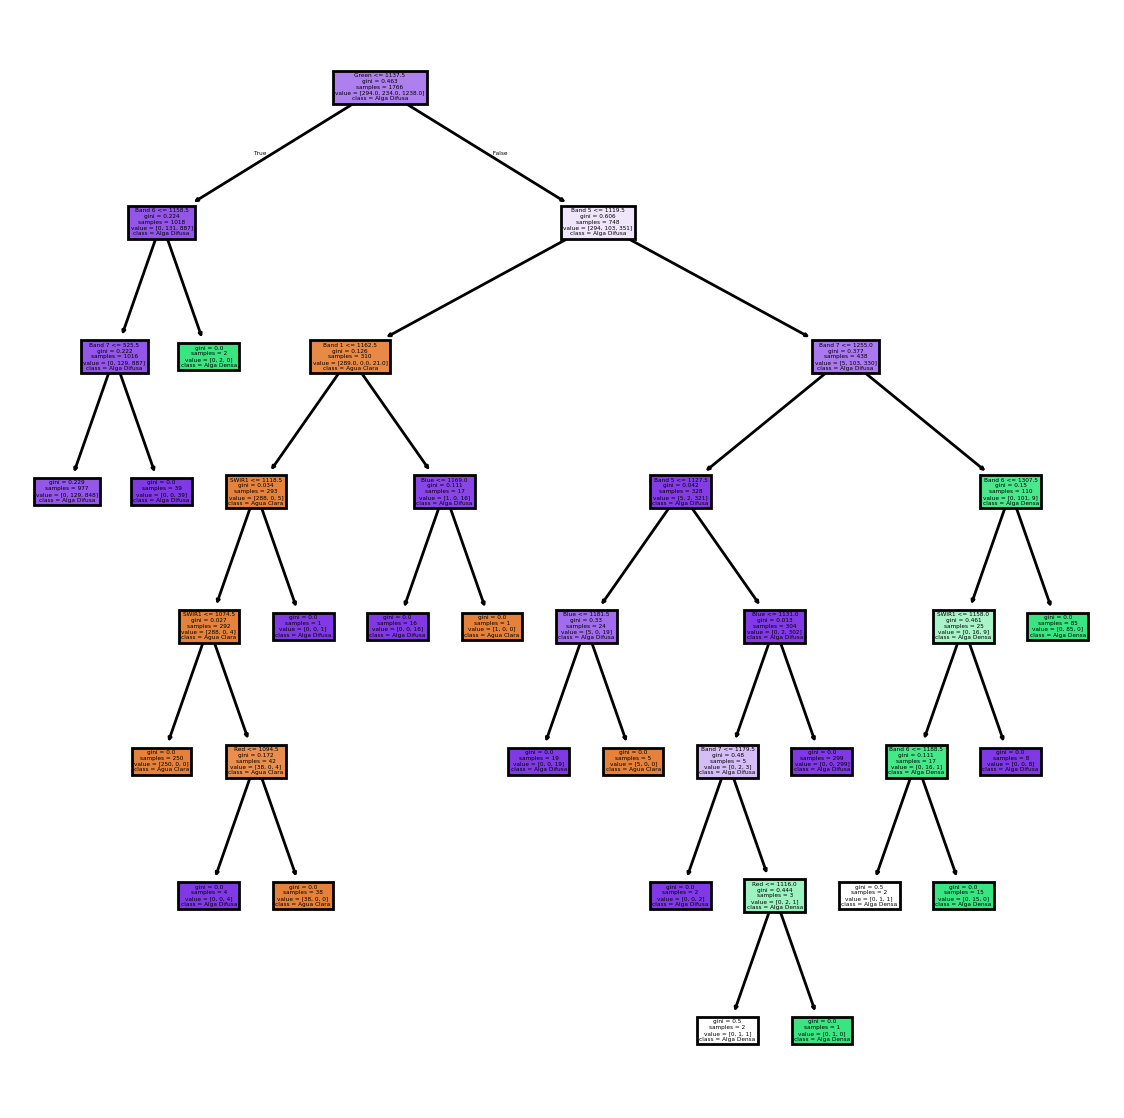

In [33]:
# Plot decision tree
fig = plt.figure(figsize = (7,7), dpi = 200)
_ = tree.plot_tree(clf4, 
                   feature_names = bandas,  
                   class_names = clases,
                   filled = True)

In [34]:
# Testing!
# build a list of max depths and see which fits best
lmd = np.arange(2,11)
scoresTest = []
scoresTrain = []

for md in lmd:
    clf = tree.DecisionTreeClassifier(max_depth = md)
    clf = clf.fit(X_train, y_train)
    Y_pred = clf.predict(X_test)
    acc_test = accuracy_score(y_test, Y_pred)
    scoresTest.append(acc_test)
    acc_train = accuracy_score(y_train, clf.predict(X_train))
    scoresTrain.append(acc_train)
    print(f'Depth {md:>2d}: Train {acc_train:.3f}, Test: {acc_test:.3f}')

# It plateaued at 2, not sure why, will check later.

Depth  2: Train 0.854, Test: 0.842
Depth  3: Train 0.914, Test: 0.924
Depth  4: Train 0.916, Test: 0.924
Depth  5: Train 0.923, Test: 0.925
Depth  6: Train 0.926, Test: 0.924
Depth  7: Train 0.926, Test: 0.924
Depth  8: Train 0.926, Test: 0.929
Depth  9: Train 0.926, Test: 0.925
Depth 10: Train 0.926, Test: 0.925


In [35]:
#look for the best score on the train set
imx = np.argmax(scoresTest)
best_prof = lmd[imx]
acc = scoresTest[imx]
print(f'The best result on the test set was obtained for a tree\nof depth {best_prof} with an accuracy of {acc:.3f}')

The best result on the test set was obtained for a tree
of depth 8 with an accuracy of 0.929


In [36]:
from sklearn.model_selection import StratifiedKFold

n_splits = 10
lmd = np.arange(2,25)
accTest = np.zeros([len(lmd),n_splits])
accTrain = np.zeros([len(lmd),n_splits])

skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
for j, (train_index, test_index) in enumerate(skf.split(X, Y)):
    print(f'fold {j+1} of {n_splits}.')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]
    for i,md in enumerate(lmd):
        clf = tree.DecisionTreeClassifier(max_depth = md)
        clf = clf.fit(X_train, y_train)
        accTest[i,j] = accuracy_score(y_test, clf.predict(X_test))
        accTrain[i,j] = accuracy_score(y_train, clf.predict(X_train))

fold 1 of 10.
fold 2 of 10.
fold 3 of 10.
fold 4 of 10.
fold 5 of 10.
fold 6 of 10.
fold 7 of 10.
fold 8 of 10.
fold 9 of 10.
fold 10 of 10.


In [37]:
print(f'\n\nAccuracy for each max_depth (rows) and the {n_splits} runs:\n')
print('*',' '.join([f'Run {i+1} ' for i in range(n_splits)]),'*')
print(accTest)



Accuracy for each max_depth (rows) and the 10 runs:

* Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10  *
[[0.75847458 0.75       0.83898305 0.73728814 0.84745763 0.85957447
  0.75744681 0.74042553 0.85106383 0.84680851]
 [0.91525424 0.89830508 0.90254237 0.8940678  0.92372881 0.91489362
  0.9106383  0.8893617  0.93191489 0.92765957]
 [0.92372881 0.90677966 0.90254237 0.91101695 0.91525424 0.91489362
  0.91914894 0.89787234 0.93191489 0.92765957]
 [0.9279661  0.90677966 0.90254237 0.91101695 0.92372881 0.91489362
  0.91914894 0.89787234 0.93617021 0.92765957]
 [0.9279661  0.90677966 0.90677966 0.91101695 0.92372881 0.9106383
  0.91914894 0.89787234 0.93191489 0.92765957]
 [0.92372881 0.90677966 0.91525424 0.91101695 0.92372881 0.9106383
  0.91914894 0.90638298 0.93191489 0.92765957]
 [0.92372881 0.90677966 0.91525424 0.91101695 0.9279661  0.9106383
  0.91489362 0.90638298 0.93191489 0.93191489]
 [0.92372881 0.90677966 0.91101695 0.91101695 0.9279661  0.9106383
 

In [38]:
#Compute averages over the K folds
scoresTest = accTest.mean(axis=1)
scoresTrain = accTrain.mean(axis=1)

#Look for the best result
imx = np.argmax(scoresTest)
best_prof = lmd[imx]
best_acc = scoresTest[imx]
print(f'The best result on the test set was obtained for a tree of depth {best_prof} and an accuracy of {best_acc:.3f}')

The best result on the test set was obtained for a tree of depth 19 and an accuracy of 0.919


In [39]:
# Use the best of all
clf12 = tree.DecisionTreeClassifier(max_depth = best_prof)
clf12 = clf12.fit(X, Y)

#Read the full image
raster_fn = path
with rasterio.open(raster_fn) as src:
    img = src.read()
    crs = src.crs
    gt = src.transform

d,x,y = s2_clip.shape

# use the model to classify the reservoir image
Y_pred = clf12.predict(s2_clip.reshape([d,x*y]).T)


In [40]:
#Remove the edges that we don't care about classifying

contorno = Y_pred.reshape([x,y])
contorno = contorno.astype('float64')
contorno[np.where(s2_mask[0] == 0)] = np.nan

In [41]:
from matplotlib.patches import Patch


In [42]:
clases

['Agua Clara', 'Alga Densa', 'Alga Difusa']

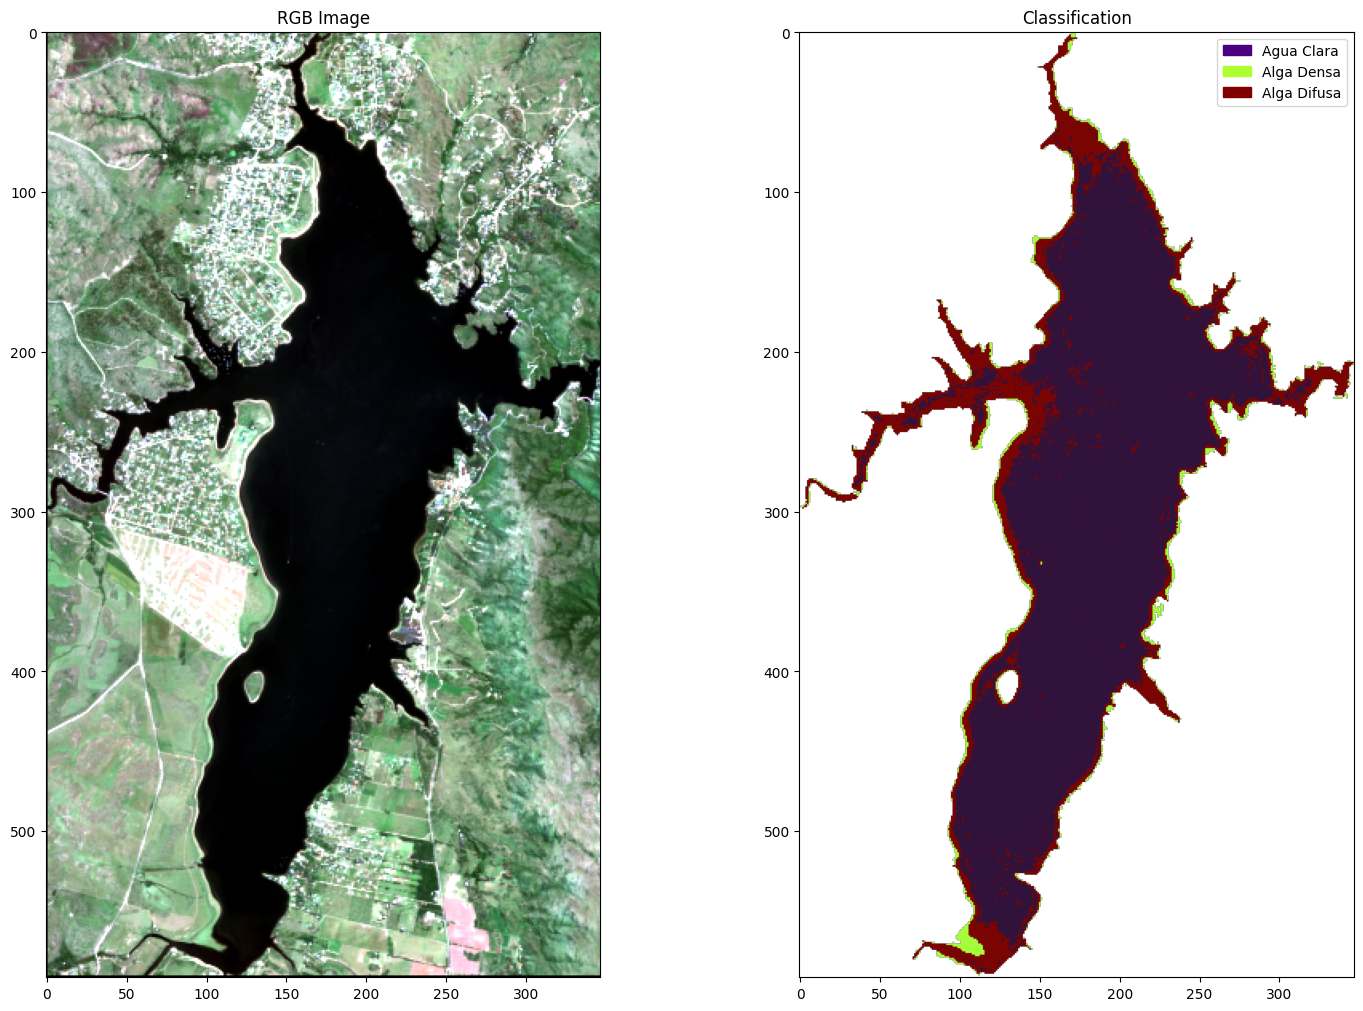

In [43]:
rgb = np.einsum('kij->ijk',nequalize(s2_clip[[3,2,1]], p=5))

# fig, ax = plt.subplots(1,3, figsize = (15,10), constrained_layout=True)
fig, ax = plt.subplots(1,2, figsize = (15,10), constrained_layout=True)
ax[0].imshow(rgb)
# ax[1].imshow(Y_pred.reshape([x,y]),cmap='gnuplot2')
# ax[2].imshow(contorno,cmap='gnuplot2')
ax[1].imshow(contorno, cmap='turbo')

patch_aguaClara = Patch(color='indigo', label=clases[0])
patch_aguaTurbia = Patch(color='greenyellow', label=clases[1])
patch_algaDif = Patch(color='maroon', label=clases[2])

ax[1].legend(handles=[patch_aguaClara,patch_aguaTurbia,patch_algaDif])

ax[0].title.set_text('RGB Image')
ax[1].title.set_text('Classification')
# ax[2].title.set_text('Embalse')
# fig.suptitle('Desicion Tree', fontsize=20)

-----------
# Random Forest

In [44]:
#Load X, Y labeled data, as in the kmeans

#Read the ROIS
with rasterio.open(path) as src:
    d = src.count #number of attributes = number of bands in the raster
    m = src.read()

nodata = -255 #choose an unusual value for nodata, different from None or np.nan (not empty nor infinite)

In [45]:
# The shp file used for training must have at least 2 columns, the first named CLASE with the name of
# each type; I used agua clara, alga densa, and alga difusa. The name chosen doesn't matter.
# The second column is the geometry of each polygon

# pols = gpd.read_file('Poligonos/Entrenamiento_2022/pol180222-2.shp')#.set_index('id') #Loads the shp file with the training polygons for the reservoir
# pols = gpd.read_file('Poligonos/Entrenamiento_2022/polCruz-2.shp')
pols = radiosMol

#In case it doesn't have the same name I used, they can be changed here,
# where in the dictionary for each dataframe value, enter the new name you want,
# for example, from id to id_clase
nombres_col = {'id':'id_clase', 'clase_1':'CLASE'} 
pols.rename(columns = nombres_col, inplace = True)

clases=list(set(pols['CLASE']))
clases.sort() #number the ROI classes alphabetically
clase_dict = {clase:i for i, clase in enumerate(clases)}
clase_dict, pols['CLASE'].value_counts()

({'Agua Clara': 0, 'Alga Densa': 1, 'Alga Difusa': 2},
 CLASE
 Alga Difusa    10
 Agua Clara      8
 Alga Densa      2
 Name: count, dtype: int64)

In [46]:
#Prepare collection of labeled attributes. Starts with 0 data points
X = np.zeros([0,d],dtype = np.float32) #array with all the attributes
Y = np.zeros([0],dtype=int)            #array with their labels

with rasterio.open(path) as src:
    for index, row in pols.iterrows():
        poli = row['geometry']
        clase = row['CLASE']
        clip, _transform = mask(src, [poli], crop=True,nodata=None)
        d,x,y = clip.shape
        D = list(clip.reshape([d,x*y]).T)
        D = [p for p in D if (not (p==None).prod())]
        DX = np.array(D)        
        DY = np.repeat(clase_dict[clase],len(D))
        X = np.concatenate((X,DX))
        Y = np.concatenate((Y,DY))

In [47]:
L = list(Y)
E = set(L)

pixels_por_clase = {clases[y]:L.count(y) for y in E}

In [48]:
for clase in clases:
    print(f"{clase:>15s}: {pixels_por_clase[clase]}, 25%: {pixels_por_clase[clase]*0.25}") #Number of pixels per class

     Agua Clara: 392, 25%: 98.0
     Alga Densa: 312, 25%: 78.0
    Alga Difusa: 1651, 25%: 412.75


In [49]:
#split into train and test
X_train_rf, X_test_rf, Y_train_rf, Y_test_rf = train_test_split(X, Y, test_size = .25)

#train a model
clf = RandomForestClassifier(n_estimators = 100, max_depth = 12)
clf.fit(X_train_rf, Y_train_rf)

#evaluate it
Y_pred_rf = clf.predict(X_test_rf)
print("Accuracy:", metrics.accuracy_score(Y_test_rf, Y_pred_rf))

Accuracy: 0.9185059422750425


In [50]:
# Parameters of interest
M = confusion_matrix(Y_test_rf, Y_pred_rf)
print('Confusion matrix:\n',M) #If this gives me a diagonal, be suspicious

acc = accuracy_score(Y_test_rf, Y_pred_rf)
print(f'accuracy: {acc:.2f}')

k = kappa(Y_test_rf, Y_pred_rf)
print(f'kappa index: {k:.2f}')

Confusion matrix:
 [[104   0   0]
 [  0  39  42]
 [  3   3 398]]
accuracy: 0.92
kappa index: 0.82


In [51]:
n_splits = 10
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
print(skf)

valores_prof = [2,3,4,5,10,15,20,30]
valores_estim = [10,25,50]#100,120,150,180,200]

resultados_test = np.zeros((n_splits, len(valores_prof), len(valores_estim)))
resultados_train = np.zeros((n_splits, len(valores_prof), len(valores_estim)))

split = 0
for train_index, test_index in skf.split(X,Y):
    print(f"Fold {split + 1}:")
    for i,d in enumerate(valores_prof):
        print(f" - trees of depth {d}")
        for j,n in enumerate(valores_estim):
            X_train_rf, X_test_rf = X[train_index,:], X[test_index,:]
            Y_train_rf, Y_test_rf = Y[train_index], Y[test_index]
            model = RandomForestClassifier(n_estimators = n, max_depth = d)
            model.fit(X_train_rf, Y_train_rf) 
            Y_pred_rf = model.predict(X_test_rf)
            Y_pred_train_rf = model.predict(X_train_rf)
            acc_test = metrics.accuracy_score(Y_test_rf, Y_pred_rf)
            acc_train = metrics.accuracy_score(Y_train_rf, Y_pred_train_rf)
            resultados_test[split, i, j] = acc_test
            resultados_train[split, i, j] = acc_train
            
            # M = confusion_matrix(X_test_rf, Y_pred_train_rf)
            # print('Confusion matrix:\n',M) #If this gives me a diagonal, be suspicious
            # print("Accuracy:", metricsaccuracy_score(X_test_rf, Y_pred_train_r))
            # k = kappa(X_test_rf, Y_pred_train_rf)
            # print(f'kappa index: {k:.2f}')
            
    split += 1

StratifiedKFold(n_splits=10, random_state=None, shuffle=True)
Fold 1:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees of depth 5
 - trees of depth 10
 - trees of depth 15
 - trees of depth 20
 - trees of depth 30
Fold 2:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees of depth 5
 - trees of depth 10
 - trees of depth 15
 - trees of depth 20
 - trees of depth 30
Fold 3:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees of depth 5
 - trees of depth 10
 - trees of depth 15
 - trees of depth 20
 - trees of depth 30
Fold 4:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees of depth 5
 - trees of depth 10
 - trees of depth 15
 - trees of depth 20
 - trees of depth 30
Fold 5:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees of depth 5
 - trees of depth 10
 - trees of depth 15
 - trees of depth 20
 - trees of depth 30
Fold 6:
 - trees of depth 2
 - trees of depth 3
 - trees of depth 4
 - trees o

In [52]:
promedios_test = np.mean(resultados_test, axis = 0) 

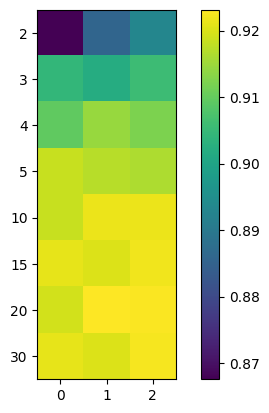

In [53]:
fig, ax = plt.subplots()
axx = ax.imshow(promedios_test)

# Show all ticks and label them with the respective list entries
ax.set_yticks(np.arange(len(valores_prof)), labels=[str(v) for v in valores_prof])
ax.set_xticks(np.arange(len(valores_estim)))#, labels=valores_estim)
fig.colorbar(axx)

In [54]:
ind = np.unravel_index(np.argmax(promedios_test, axis=None), promedios_test.shape)
opt_d = valores_prof[ind[0]]
opt_n = valores_estim[ind[1]]
max_acc = promedios_test[ind]

print(f"The best average was obtained for depth {opt_d} and {opt_n} trees, with an accuracy of {max_acc:.3f}")

The best average was obtained for depth 20 and 25 trees, with an accuracy of 0.923


In [55]:
#train a model
X_train_rf, X_test_rf, Y_train_rf, Y_test_rf = train_test_split(X, Y, test_size = .25)
clf = RandomForestClassifier(n_estimators = opt_d, max_depth = opt_n)
clf.fit(X_train_rf, Y_train_rf)

#Read the full image
raster_fn = path
with rasterio.open(raster_fn) as src:
    img = src.read()
    crs = src.crs
    gt = src.transform

d,x,y = s2_clip.shape

# use the model to classify the reservoir image
# Y_pred_rf = clf.predict(X_test_rf)/
Y_pred_rf = clf.predict(s2_clip.reshape([d,x*y]).T)

In [56]:
# Parameters of interest
Y_pred_test = clf.predict(X_test_rf)

M = confusion_matrix(Y_test_rf, Y_pred_test)


print('Confusion matrix:\n',M) #If this gives me a diagonal, be suspicious

print("Accuracy:",accuracy_score(Y_test_rf, Y_pred_test))

k = kappa(Y_test_rf, Y_pred_test)
print(f'kappa index: {k:.2f}')

Confusion matrix:
 [[110   0   1]
 [  0  33  37]
 [  2   4 402]]
Accuracy: 0.9252971137521222
kappa index: 0.83


In [57]:
#Remove the edges that we don't care about classifying

contorno_rf = Y_pred_rf.reshape([x,y])
contorno_rf = contorno_rf.astype('float64')
contorno_rf[np.where(s2_mask[0] == 0)] = np.nan

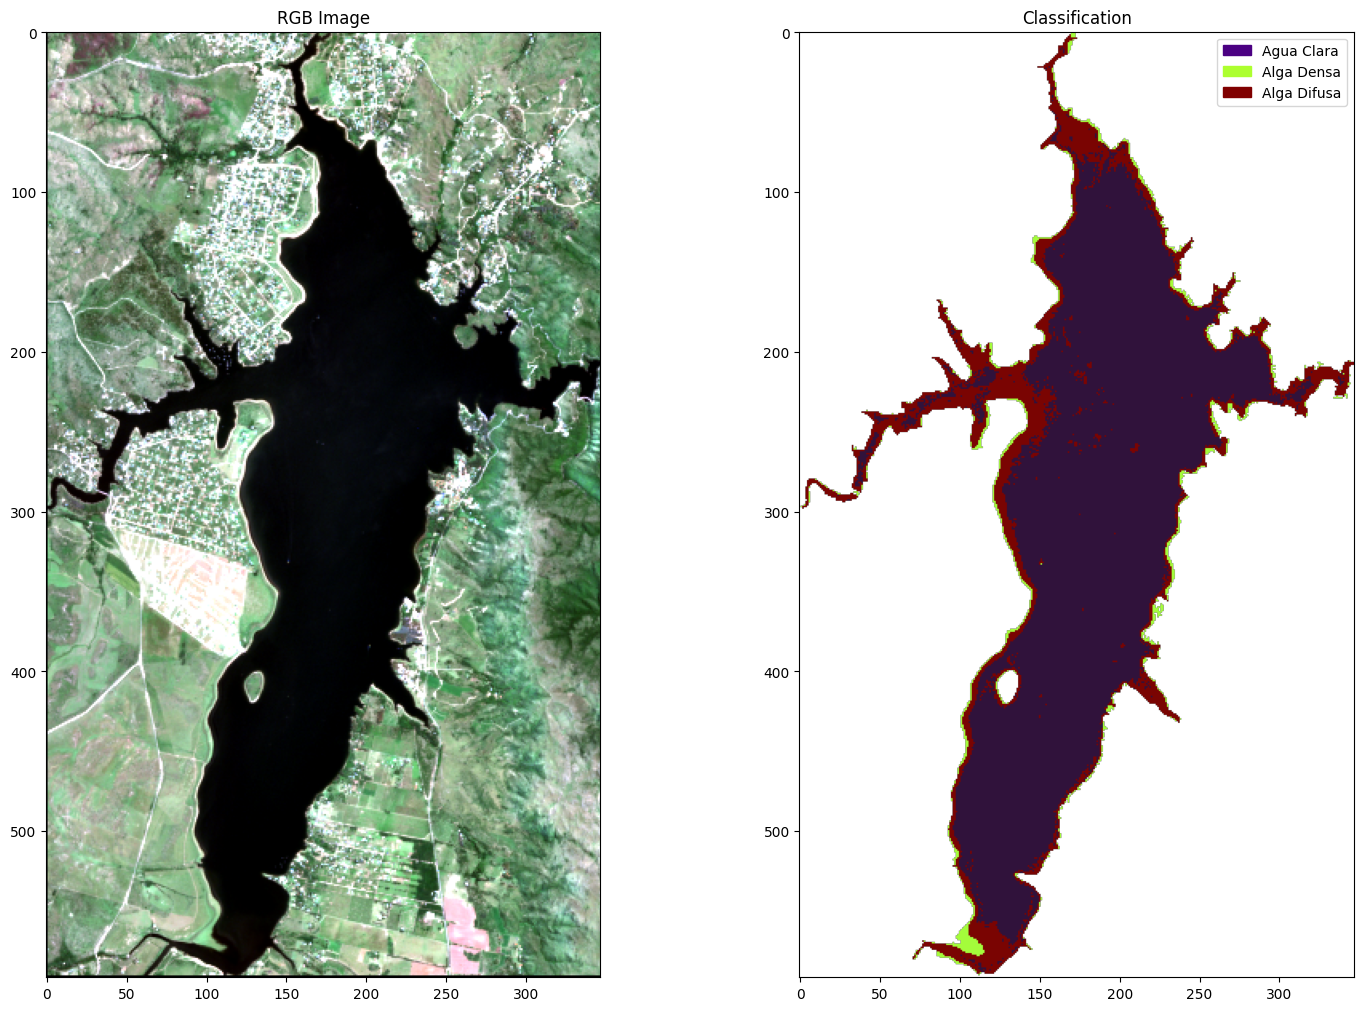

In [58]:
rgb = np.einsum('kij->ijk',nequalize(s2_clip[[3,2,1]]))

plt.style.use('default')

# fig, ax = plt.subplots(1,3, figsize = (15,10), constrained_layout=True)
fig, ax = plt.subplots(1,2, figsize = (15,10), constrained_layout=True)
ax[0].imshow(rgb)
# ax[1].imshow(Y_pred_rf.reshape([x,y]),cmap='gnuplot2')
# ax[2].imshow(contorno_rf,cmap='gnuplot2')

# colors = ['blue',
#           'yellow',
#           'darkgreen',
#           'maroon']
# cmap = matplotlib.colors.ListedColormap(colors)
ax[1].imshow(contorno_rf,cmap='turbo')

patch_aguaClara = Patch(color='indigo', label=clases[0])
patch_aguaTurbia = Patch(color='greenyellow', label=clases[1])
patch_algaDif = Patch(color='maroon', label=clases[2])
ax[1].legend(handles=[patch_aguaClara,patch_aguaTurbia,patch_algaDif])

ax[0].title.set_text('RGB Image')
ax[1].title.set_text('Classification')
# ax[2].title.set_text('Embalse')
# fig.suptitle('Random Forest', fontsize=20)

In [59]:
labelss = []
for a in clase_dict.keys():
    labelss.append(a) 
    
df_cm = pd.DataFrame(M, index = labelss, columns = labelss)
df_cm

,Agua Clara,Alga Densa,Alga Difusa
Agua Clara,110,0,1
Alga Densa,0,33,37
Alga Difusa,2,4,402


<Axes: >

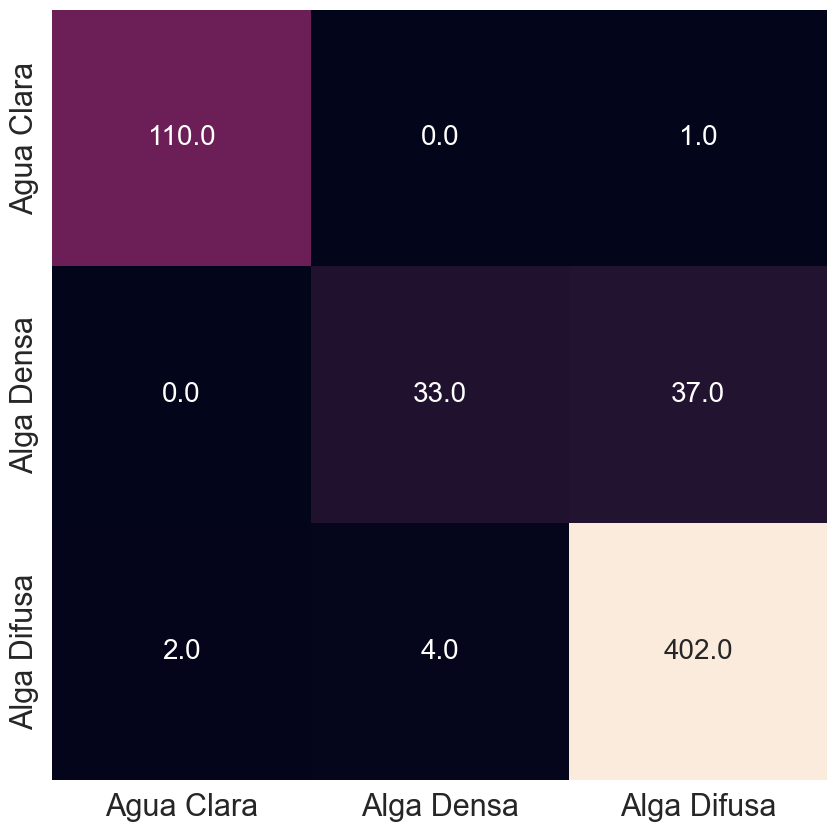

In [60]:
plt.figure(figsize = (10,10))
sns.set(font_scale=2)
sns.heatmap(df_cm,annot=True, cbar=False, annot_kws={"size": 20}, fmt=".1f")